In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [2]:
DATA_FILE = Path("HEPData-ins2907010-v1-Figure_4a_cent7.csv")

df = pd.read_csv(
    DATA_FILE,
    comment="#",
    header=None,
    names=["pT","v0","stat_plus","stat_minus","sys_plus","sys_minus"],
)

df = df.astype(float).sort_values("pT").reset_index(drop=True)

# erro experimental combinado
df["sigma_exp"] = np.sqrt(df["stat_plus"]**2 + df["sys_plus"]**2)

x = df["pT"].to_numpy()
y = df["v0"].to_numpy()

print("Mean(y) =", np.mean(y))
print("Std(y)  =", np.std(y))
df.head()

Mean(y) = 0.1091660551724138
Std(y)  = 0.07559760737576557


,pT,v0,stat_plus,stat_minus,sys_plus,sys_minus,sigma_exp
0,0.55231,-0.044431,0.000092,-0.000092,0.001367,-0.001367,0.001370
1,0.64791,-0.035065,0.000129,-0.000129,0.001148,-0.001148,0.001155
2,0.74831,-0.023929,0.000124,-0.000124,0.000972,-0.000972,0.000980
3,0.84819,-0.013116,0.000134,-0.000134,0.000803,-0.000803,0.000814
4,0.94830,-0.002188,0.000137,-0.000137,0.000721,-0.000721,0.000733


In [3]:
def K_rbf(x, sigma_f, ell):
    x = np.asarray(x).reshape(-1,1)
    sqdist = (x - x.T)**2
    return sigma_f**2 * np.exp(-0.5 * sqdist / ell**2)

In [4]:
def nll_gp_rbf(theta, x, y):
    log_sigma_f, log_ell, log_sigma_n = theta
    sigma_f = np.exp(log_sigma_f)
    ell = np.exp(log_ell)
    sigma_n = np.exp(log_sigma_n)

    K = K_rbf(x, sigma_f, ell)
    Ky = K + sigma_n**2 * np.eye(len(x))

    try:
        c, lower = cho_factor(Ky)
        alpha = cho_solve((c, lower), y)
        logdet = 2*np.sum(np.log(np.diag(c)))
        lml = -0.5*y@alpha - 0.5*logdet - 0.5*len(x)*np.log(2*np.pi)
        return -lml
    except:
        return 1e50

In [5]:
init = np.log([np.std(y), 1.0, 0.1*np.std(y)])
res = minimize(nll_gp_rbf, init, args=(x,y), method="L-BFGS-B")

sigma_f, ell, sigma_n = np.exp(res.x)

print("=== RBF ===")
print("sigma_f:", sigma_f)
print("ell:", ell)
print("sigma_n:", sigma_n)
print("log marginal:", -res.fun)

=== RBF ===
sigma_f: 0.13500888570210345
ell: 2.589012149884314
sigma_n: 0.0013386245178769922
log marginal: 120.86145821893955


In [6]:
def gp_predict_rbf(x_train, y_train, x_test, sigma_f, ell, sigma_n):
    K = K_rbf(x_train, sigma_f, ell)
    Ky = K + sigma_n**2*np.eye(len(x_train))
    Ks = sigma_f**2 * np.exp(-0.5*(x_test.reshape(-1,1)-x_train.reshape(1,-1))**2/ell**2)
    Kss = K_rbf(x_test, sigma_f, ell)

    c, lower = cho_factor(Ky)
    alpha = cho_solve((c, lower), y_train)

    mu = Ks @ alpha
    v = cho_solve((c, lower), Ks.T)
    cov = Kss - Ks @ v
    var = np.clip(np.diag(cov),0,np.inf)

    return mu, var

In [7]:
def fit_white(y):
    m = np.mean(y)
    sigma = np.std(y)
    return m, sigma

mean_white, sigma_white = fit_white(y)

print("=== White baseline ===")
print("mean:", mean_white)
print("sigma:", sigma_white)

=== White baseline ===
mean: 0.1091660551724138
sigma: 0.07559760737576557


In [8]:
x_star = np.linspace(x.min(), x.max(), 400)

# RBF
mu_rbf, var_rbf_latent = gp_predict_rbf(x, y, x_star, sigma_f, ell, sigma_n)
sigma_rbf_obs = np.sqrt(var_rbf_latent + sigma_n**2)

# White baseline
mu_white = np.full_like(x_star, mean_white)
sigma_white_obs = np.full_like(x_star, sigma_white)

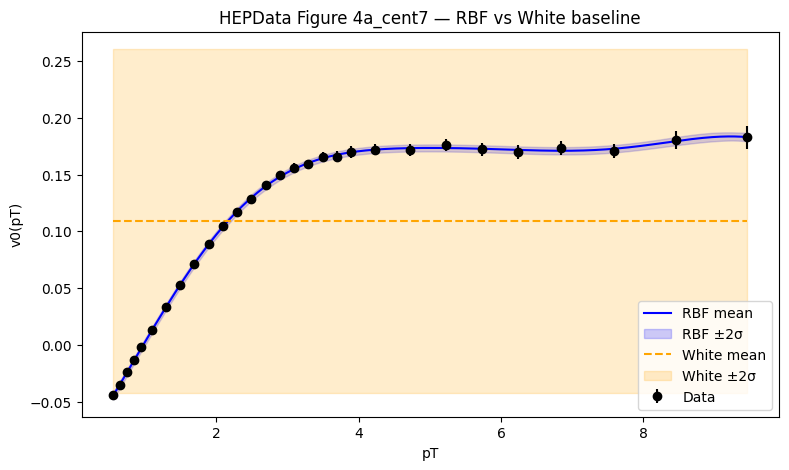

In [9]:
plt.figure(figsize=(9,5))

# dados
plt.errorbar(x, y, yerr=df["sigma_exp"], fmt='o', color='black', label="Data")

# RBF
plt.plot(x_star, mu_rbf, color="blue", label="RBF mean")
plt.fill_between(
    x_star,
    mu_rbf - 2*sigma_rbf_obs,
    mu_rbf + 2*sigma_rbf_obs,
    color="blue",
    alpha=0.2,
    label="RBF ±2σ"
)

# White
plt.plot(x_star, mu_white, color="orange", linestyle="--", label="White mean")
plt.fill_between(
    x_star,
    mu_white - 2*sigma_white_obs,
    mu_white + 2*sigma_white_obs,
    color="orange",
    alpha=0.2,
    label="White ±2σ"
)

plt.xlabel("pT")
plt.ylabel("v0(pT)")
plt.legend()
plt.title("HEPData Figure 4a_cent7 — RBF vs White baseline")
plt.show()

In [10]:
print("Log marginal RBF:", -res.fun)

# log likelihood do white como modelo independente
log_like_white = -0.5*np.sum((y-mean_white)**2/sigma_white**2) \
                 -0.5*len(y)*np.log(2*np.pi*sigma_white**2)

print("Log marginal White:", log_like_white)

Log marginal RBF: 120.86145821893955
Log marginal White: 33.73837123528379
